In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
valor_amostras = 16
dataset = "dataset_sem_tempo_com_janelamento_16_amostras.csv"
df_original = pd.read_csv("dataset_sem_tempo_com_janelamento_16_amostras.csv")

def dividir_dados(caminho_arquivo, num_massflows=5):
    caminho_arquivo = Path(caminho_arquivo)
    
    if not caminho_arquivo.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {caminho_arquivo}")

    df = pd.read_csv(caminho_arquivo)
    
    massflow_cols = [f'massFlow_{i}' for i in range(1, num_massflows + 1)] 
    dados = df[massflow_cols].values.astype(np.float32)
    
    tamanho_treino = int(len(dados) * 0.75)
    treino_dados = dados[:tamanho_treino]
    validacao_dados = dados[tamanho_treino:]
    
    return {
        "x_train": torch.tensor(treino_dados),
        "x_val": torch.tensor(validacao_dados)
    }

In [3]:
class BaseModel(nn.Module):
    def __init__(self, **kwargs):
        super(BaseModel, self).__init__()
        self.model = None  # Placeholder for model architecture in subclasses
        self.optimizer = None
        self.criterion = None
        self.kwargs = kwargs

    def compile_model(self, optimizer_fn=optim.Adam, learning_rate=0.001, criterion_fn=nn.MSELoss):
        """Set up the optimizer and loss function."""
        self.optimizer = optimizer_fn(self.parameters(), lr=learning_rate)
        self.criterion = criterion_fn()
        # print("Model compiled with custom optimizer and loss function.")

    def train_model(self, x_train, y_train, loss_function, epochs=10, batch_size=32, validation_split=0.2):
        """Train the model on the provided dataset."""
        dataset_size = len(x_train)
        split = int(dataset_size * (1 - validation_split))
        train_data = x_train[:split], y_train[:split]
        val_data = x_train[split:], y_train[split:]

        for epoch in range(epochs):
            self.train()
            total_loss = 0
            for i in range(0, split, batch_size):
                x_batch = train_data[0][i:i + batch_size]
                y_batch = train_data[1][i:i + batch_size]

                self.optimizer.zero_grad()
                predictions = self(x_batch)
                loss = loss_function(predictions, y_batch)
                loss.backward()
                self.optimizer.step()
                total_loss += loss.item()

            # Validation
            if validation_split > 0:
                self.eval()
                with torch.no_grad():
                    val_predictions = self(val_data[0])
                    val_loss = loss_function(val_predictions, val_data[1])
                # print(f"Epoch {epoch + 1}, Train Loss: {total_loss:.8f}, Val Loss: {val_loss:.8f}")
            else:
                # print(f"Epoch {epoch + 1}, Loss: {total_loss:.8f}")
                pass

    def evaluate(self, x_test, y_test, loss_function):
        """Evaluate the model on test data."""
        self.eval()
        with torch.no_grad():
            predictions = self(x_test)
            test_loss = loss_function(predictions, y_test)
        print(f"Test loss: {test_loss.item()}")
        return test_loss.item()

    def predict(self, x):
        """Generate predictions on new data."""
        self.eval()
        with torch.no_grad():
            predictions = self(x)
        return predictions

    def save_model(self, file_path):
        """Save the model to a file."""
        torch.save(self.state_dict(), file_path)
        print(f"Model saved to {file_path}")

    def load_model(self, file_path):
        """Load the model from a file."""
        self.load_state_dict(torch.load(file_path, weights_only=True))
        print(f"Model loaded from {file_path}")

In [4]:
class Autoencoder(BaseModel):
    def __init__(self, **kwargs):
        super(Autoencoder, self).__init__(**kwargs)
        
        input_dim = kwargs.get("input_dim", 1)
        latent_dim = kwargs.get("latent_dim", 32)  # dimensão específica para o bottleneck
        hidden_dim = kwargs.get("hidden_dim", 64)  # Dimensão das camadas intermediárias
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),  
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

        self.latent_output = None  # Attribute to store the bottleneck layer output
        self.loss_function = nn.MSELoss()  # Set MSE loss as default for Autoencoder

    def forward(self, x):
        """Define the forward pass for encoding and decoding, storing bottleneck output."""
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

    def compile_autoencoder(self, learning_rate=0.001):
        """Compile with optimizer and loss function specifically for reconstruction."""
        super().compile_model(optimizer_fn=torch.optim.Adam, learning_rate=learning_rate, criterion_fn=nn.MSELoss)
        self.loss_function = nn.MSELoss()  # Set loss function to MSE for reconstruction
    
    def train_model(self, dataset, epochs=10, batch_size=32, shuffle=True):
        """Train the autoencoder and track loss over epochs."""

        # Extract training data
        x_train = dataset["x_train"]
        # Extract validation data (optional)
        x_val = dataset.get("x_val", None)

        # Initialize lists to store loss values
        self.train_losses = []
        self.val_losses = [] if x_val is not None else None

        # Ensure optimizer is set in compile_model
        if self.optimizer is None:
            raise ValueError("Optimizer not set. Please call `compile_model` to set it up.")
        
        # Shuffle data if requested
        if shuffle:
            indices = torch.randperm(len(x_train))
            x_train = x_train[indices]

        dataset_size = len(x_train)

        for epoch in range(epochs):
            self.train()
            total_loss = 0
            for i in range(0, dataset_size, batch_size):
                x_batch = x_train[i:i + batch_size]
                self.optimizer.zero_grad()
                _, predictions = self(x_batch)
                loss = self.loss_function(predictions, x_batch)  # Use the default MSE loss
                loss.backward()
                self.optimizer.step()
                total_loss += loss.item()

            # Store average loss for this epoch
            avg_train_loss = total_loss / dataset_size
            self.train_losses.append(avg_train_loss)

            # Validation
            if x_val is not None:
                self.eval()
                with torch.no_grad():
                    _, val_predictions = self(x_val)
                    val_loss = self.loss_function(val_predictions, x_val).item()
                self.val_losses.append(val_loss)
                print(f"Epoch {epoch + 1}, Train Loss: {avg_train_loss:.8f}, Val Loss: {val_loss:.8f}")
            else:
                print(f"Epoch {epoch + 1}, Loss: {avg_train_loss:.8f}")
                pass
        
    def evaluate(self, x_test, y_test):
        """Evaluate the autoencoder on a test set using reconstruction loss (MSE)."""
        self.eval()  # Set model to evaluation mode
        with torch.no_grad():
            reconstructed = self(x_test)
            test_loss = self.criterion(reconstructed, y_test)  # MSE loss
        print(f"Test Loss (MSE): {test_loss.item():.8f}")
        return test_loss.item()
    
    def evaluate_reconstruction(self, x):
        """Evaluate the reconstruction on a test set."""
        self.eval()
        with torch.no_grad():
            _, decoded = self(x)
            loss = self.loss_function(x, decoded)
        return loss.item()


In [5]:
params = {
    
    "input_dim": valor_amostras,
    "hidden_dim": 12,
    "latent_dim":8,
    "activation_fn": nn.ReLU,
    "dropout": 0.0
        }

model = Autoencoder(**params)

lr = 0.02
model.compile_autoencoder(learning_rate=lr)
dataset = dividir_dados(dataset, num_massflows=valor_amostras)
epochs = 200
batch_size = 32
x_train = dataset["x_train"]  

# Mantendo uma cópia dos dados originais
x_train_original = x_train.clone()

# Treinando o modelo
model.train_model(
    dataset=dataset,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=False
)

Epoch 1, Train Loss: 0.00126058, Val Loss: 0.00486891
Epoch 2, Train Loss: 0.00008249, Val Loss: 0.00068733
Epoch 3, Train Loss: 0.00002786, Val Loss: 0.00074566
Epoch 4, Train Loss: 0.00001481, Val Loss: 0.00023160
Epoch 5, Train Loss: 0.00000719, Val Loss: 0.00016763
Epoch 6, Train Loss: 0.00000579, Val Loss: 0.00014856
Epoch 7, Train Loss: 0.00000510, Val Loss: 0.00011963
Epoch 8, Train Loss: 0.00000477, Val Loss: 0.00011772
Epoch 9, Train Loss: 0.00000457, Val Loss: 0.00011255
Epoch 10, Train Loss: 0.00000461, Val Loss: 0.00011196
Epoch 11, Train Loss: 0.00000454, Val Loss: 0.00010917
Epoch 12, Train Loss: 0.00000450, Val Loss: 0.00010789
Epoch 13, Train Loss: 0.00000444, Val Loss: 0.00010691
Epoch 14, Train Loss: 0.00000440, Val Loss: 0.00010601
Epoch 15, Train Loss: 0.00000435, Val Loss: 0.00010543
Epoch 16, Train Loss: 0.00000431, Val Loss: 0.00010496
Epoch 17, Train Loss: 0.00000426, Val Loss: 0.00010466
Epoch 18, Train Loss: 0.00000423, Val Loss: 0.00010451
Epoch 19, Train Los

In [6]:
# Avaliando o modelo após o treinamento ################### PCA NAO ESTOU TESTANDO

# Geração da representação latente
model.eval()
with torch.no_grad():  
    latent_representation = model.encoder(x_train_original)  

# PCA e visualização
latent_representation = latent_representation.numpy()
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_representation)

# plt.figure(figsize=(8, 6))
# plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=np.arange(len(latent_2d)), cmap='viridis', alpha=0.6)
# plt.colorbar(label='Índice da Amostra')
# plt.title("Representação 2D do Espaço Latente (PCA)")
# plt.xlabel("Componente Principal 1")
# plt.ylabel("Componente Principal 2")

#plt.show()

# Reconstruindo a partir dos dados originais
with torch.no_grad():
    _, reconstruido = model(x_train_original)  # Obter a saída do decodificador

reconstruido = reconstruido.numpy()

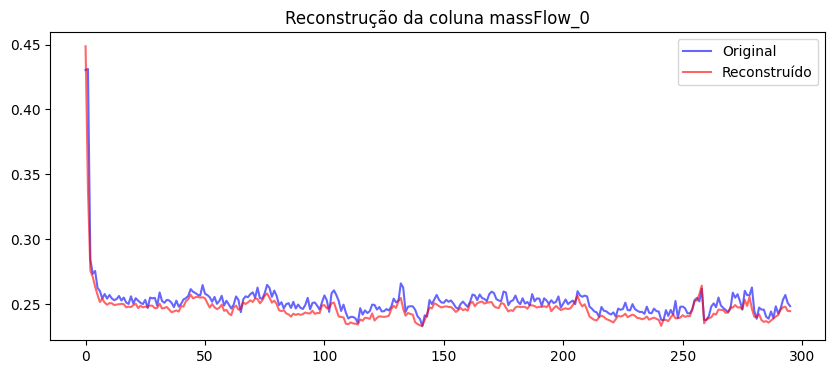

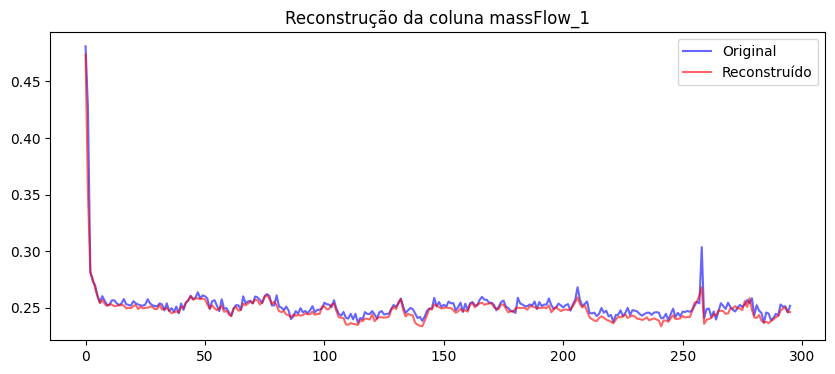

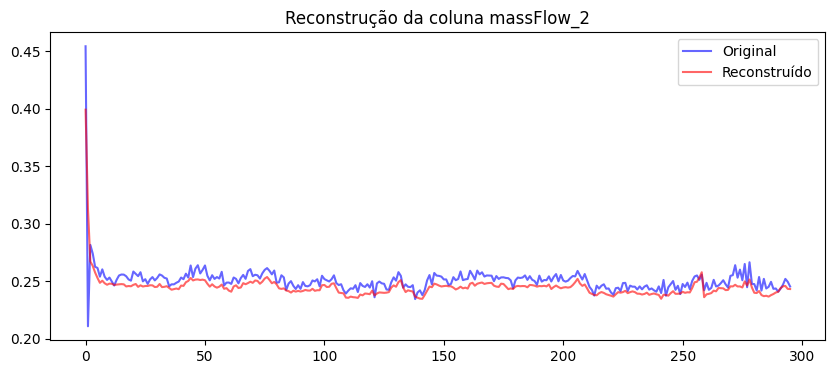

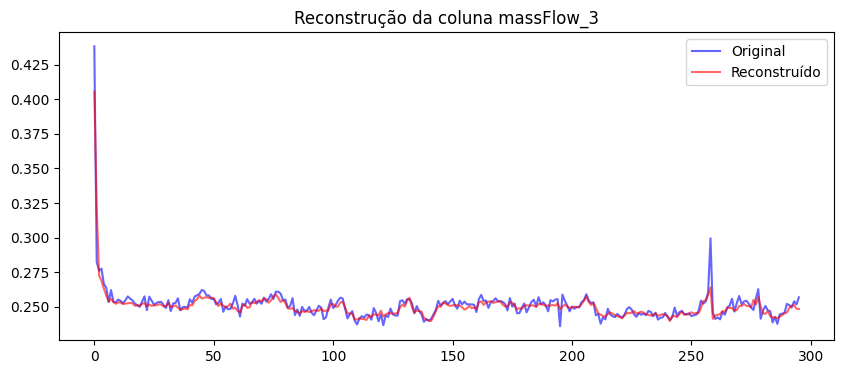

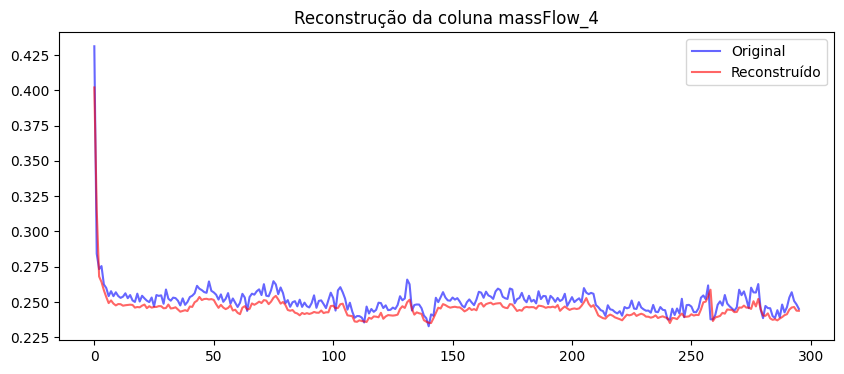

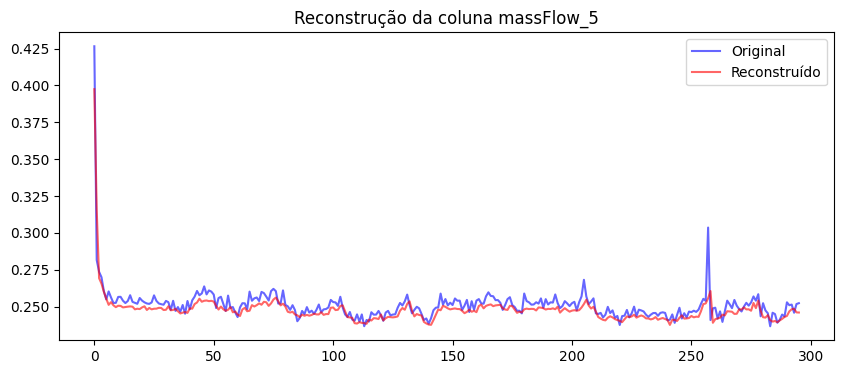

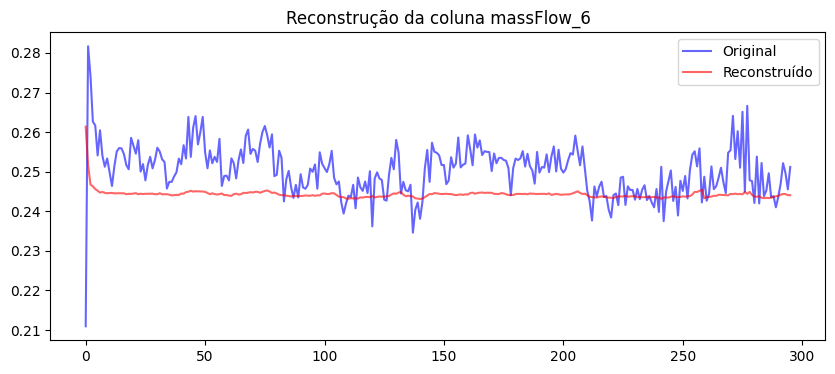

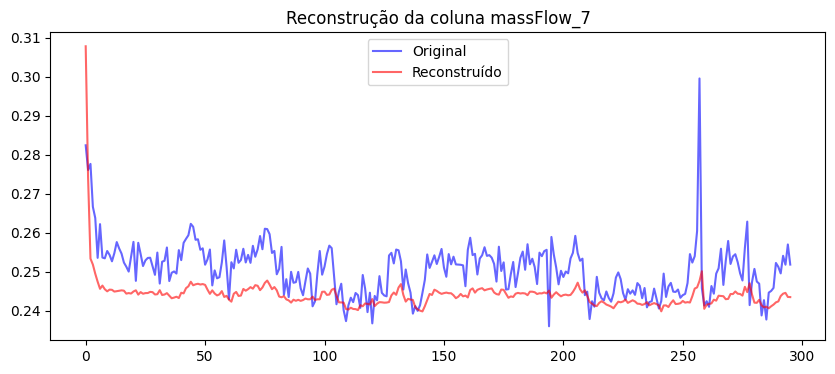

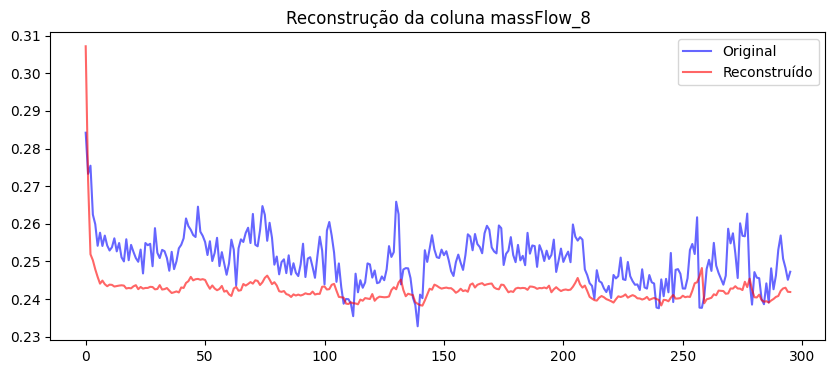

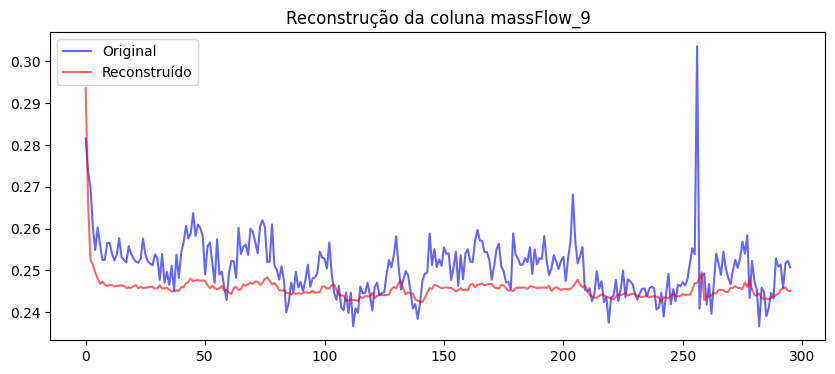

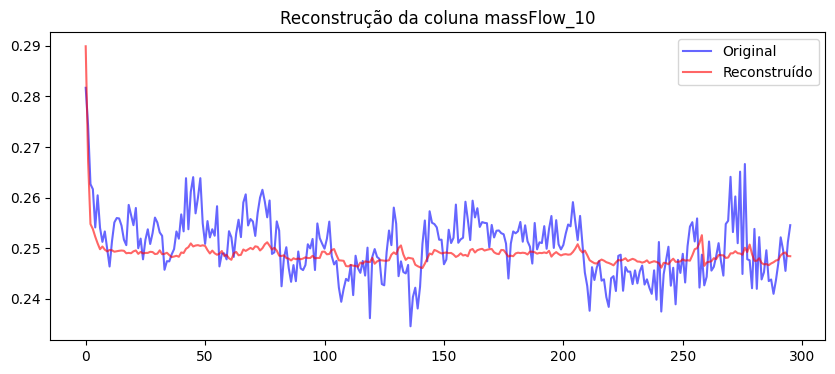

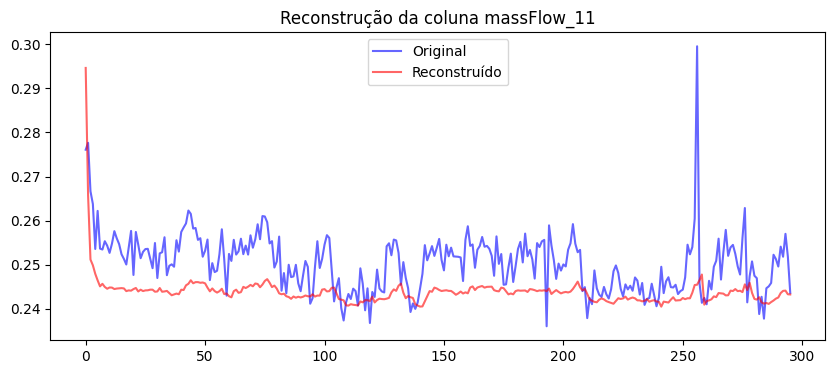

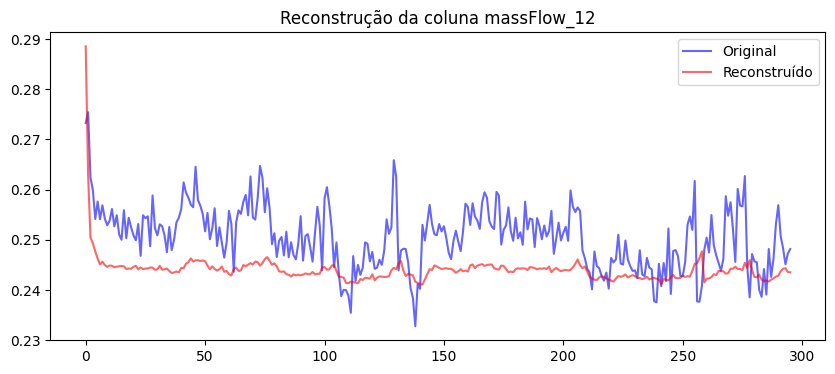

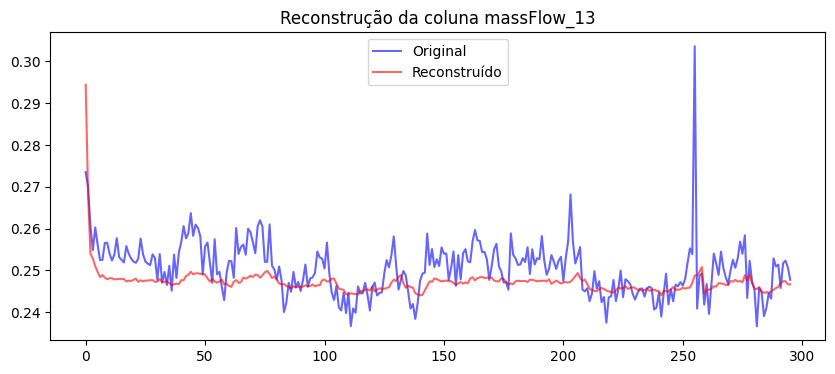

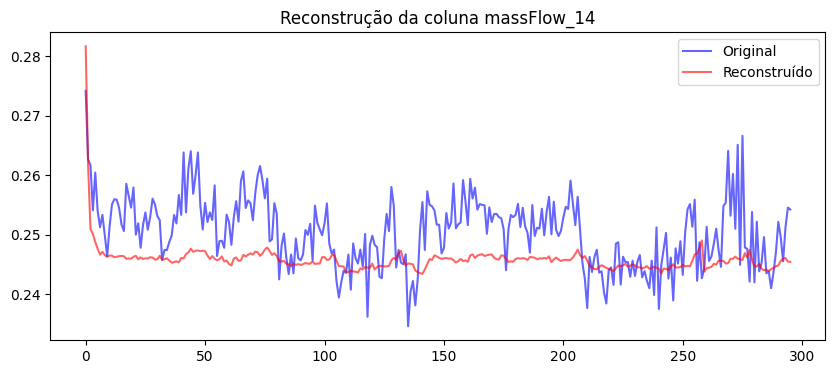

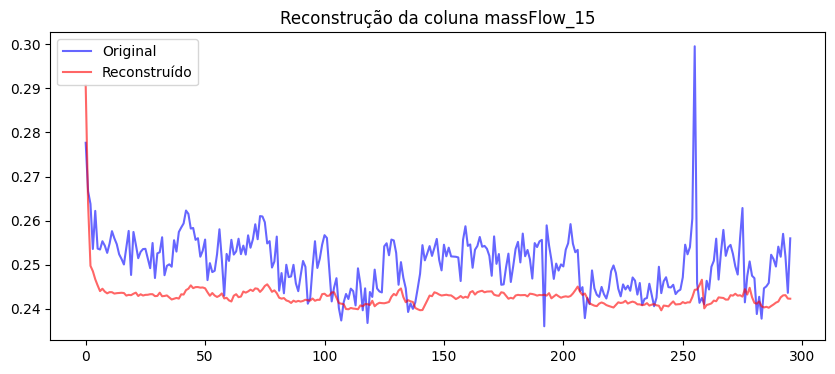

In [7]:
original = x_train_original.numpy()

# Plot para cada feature
for i in range(original.shape[1]):
    plt.figure(figsize=(10, 4))
    plt.plot(original[:, i], label='Original', color='blue', alpha=0.6)
    plt.plot(reconstruido[:, i], label='Reconstruído', color='red', alpha=0.6)
    plt.title(f'Reconstrução da coluna massFlow_{i}')
    plt.legend()
    plt.show()

In [10]:
# Supondo que:
# x_train_original é um tensor PyTorch de formato (amostras, features)
# reconstruido é um array numpy de formato (amostras, features)

# Converter tudo para numpy se necessário
if isinstance(x_train_original, torch.Tensor):
    original_np = x_train_original.numpy()
else:
    original_np = x_train_original

if isinstance(reconstruido, torch.Tensor):
    reconstruido_np = reconstruido.numpy()
else:
    reconstruido_np = reconstruido

C:\Users\PC-1\AppData\Local\Temp\ipykernel_18852\559466791.py:22: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


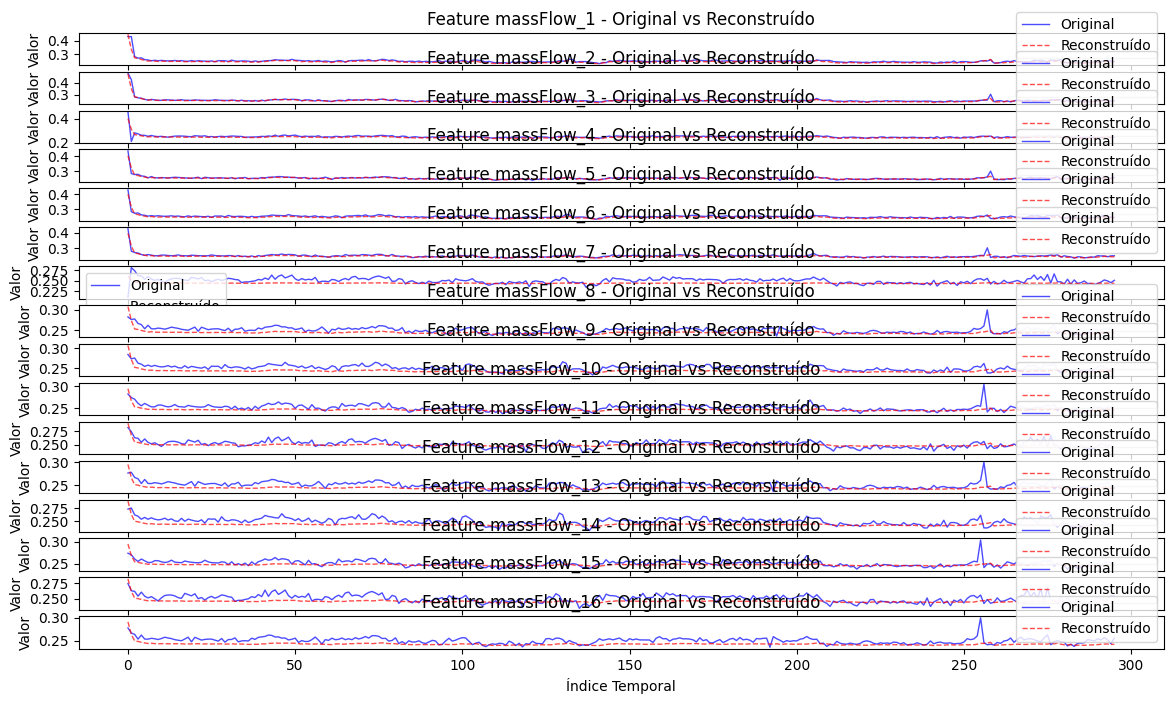

In [11]:
num_features = original_np.shape[1]
time_steps = np.arange(original_np.shape[0])

plt.figure(figsize=(14, 8))

for feature_idx in range(num_features):
    plt.subplot(num_features, 1, feature_idx+1)
    
    # Plot original vs reconstruído para cada feature
    plt.plot(time_steps, original_np[:, feature_idx], 
             'b-', label='Original', alpha=0.7, linewidth=1)
    plt.plot(time_steps, reconstruido_np[:, feature_idx], 
             'r--', label='Reconstruído', alpha=0.7, linewidth=1)
    
    plt.title(f'Feature massFlow_{feature_idx+1} - Original vs Reconstruído')
    plt.ylabel('Valor')
    plt.legend()
    
    if feature_idx == num_features-1:
        plt.xlabel('Índice Temporal')

plt.tight_layout()
plt.show()


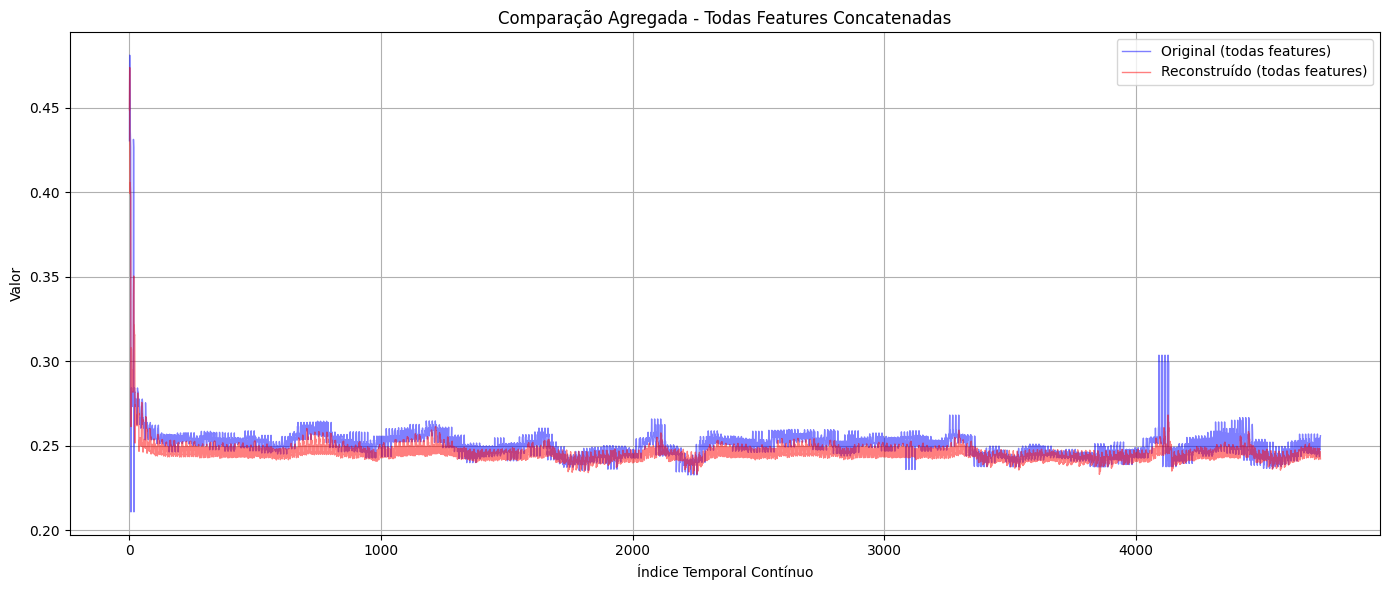

In [12]:
# Plot agregado de todas as features
plt.figure(figsize=(14, 6))

# Concatenar todas as features (achatando o array)
original_flat = original_np.flatten()
reconstruido_flat = reconstruido_np.flatten()
time_steps_flat = np.arange(len(original_flat))

plt.plot(time_steps_flat, original_flat, 
         'b-', label='Original (todas features)', alpha=0.5, linewidth=1)
plt.plot(time_steps_flat, reconstruido_flat, 
         'r-', label='Reconstruído (todas features)', alpha=0.5, linewidth=1)

plt.title('Comparação Agregada - Todas Features Concatenadas')
plt.xlabel('Índice Temporal Contínuo')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:

num_massflows = valor_amostras  # ou o número correto para seu caso##########################################################################
massflow_cols = [f'massFlow_{i}' for i in range(1, num_massflows+1)]
dados_originais = df_original[massflow_cols].values.astype(np.float32)


with torch.no_grad():
    dados_tensor = torch.tensor(dados_originais)
    _, dados_reconstruidos_tensor = model(dados_tensor)
    dados_reconstruidos = dados_reconstruidos_tensor.numpy()


df_reconstruido = df_original.copy()


for i, col in enumerate(massflow_cols):
    df_reconstruido[col] = dados_reconstruidos[:, i]


caminho_saida = "AA_dados_reconstruidos.csv"
df_reconstruido.to_csv(caminho_saida, index=False)

print(f"Arquivo reconstruído salvo em: {caminho_saida}")
print("\nExemplo das primeiras linhas:")
print(df_reconstruido.head())

Arquivo reconstruído salvo em: AA_dados_reconstruidos.csv

Exemplo das primeiras linhas:
   massFlow_1  massFlow_2  massFlow_3  massFlow_4  massFlow_5  massFlow_6  \
0    0.448685    0.473616    0.399344    0.405496    0.401992    0.397448   
1    0.338261    0.350394    0.312938    0.321275    0.315379    0.315615   
2    0.275869    0.281164    0.267304    0.272681    0.268076    0.269280   
3    0.270884    0.275618    0.263440    0.268893    0.264179    0.265582   
4    0.263312    0.267211    0.257651    0.263129    0.258298    0.259961   

   massFlow_7  massFlow_8  massFlow_9  massFlow_10  massFlow_11  massFlow_12  \
0    0.261388    0.307787    0.307169     0.293591     0.289882     0.294628   
1    0.251639    0.274093    0.271612     0.266203     0.267327     0.265747   
2    0.246747    0.253369    0.251912     0.252538     0.254780     0.251163   
3    0.246299    0.251845    0.250321     0.251325     0.253779     0.249864   
4    0.245626    0.249497    0.247921     0.2495

In [14]:
amostra_teste = torch.tensor(dados_originais[:1])  # Pega a primeira amostra
with torch.no_grad():
    latent, _ = model(amostra_teste)

dimensao_latente = latent.shape[1]
print(f"Dimensão do espaço latente: {dimensao_latente}")

Dimensão do espaço latente: 8


In [15]:
with torch.no_grad():
    dados_tensor = torch.tensor(dados_originais)
    latent_representations, _ = model(dados_tensor)
    latent_np = latent_representations.numpy()

# Criar DataFrame com colunas 'massflow_1', 'massflow_2', etc.
df_latent = pd.DataFrame(latent_np, 
                         columns=[f'massFlow_{i+1}' for i in range(latent_np.shape[1])])

# Extrair o label (por exemplo, 'anomaly') e garantir que ele seja a última coluna
label_col = df_original['anomaly'].reset_index(drop=True)  # Ajustar se o nome do label for diferente
df_latent['anomaly'] = label_col

# Salvar o DataFrame
caminho_latente = "AA_espaco_latente.csv"
df_latent.to_csv(caminho_latente, index=False)

print(f"\nArquivo do espaço latente salvo em: {caminho_latente}")
print("\nExemplo da estrutura:")
print(df_latent.head())


Arquivo do espaço latente salvo em: AA_espaco_latente.csv

Exemplo da estrutura:
   massFlow_1  massFlow_2  massFlow_3  massFlow_4  massFlow_5  massFlow_6  \
0    0.523651    0.107317   -0.483982   -0.191905    0.098089    0.182846   
1    0.294519    0.069569   -0.228921   -0.103014    0.023994    0.101644   
2    0.194958    0.020605   -0.071948   -0.012629    0.011279    0.036092   
3    0.184752    0.018100   -0.060706   -0.008362    0.008441    0.032621   
4    0.169884    0.013850   -0.043235   -0.001347    0.004800    0.026808   

   massFlow_7  massFlow_8 anomaly  
0    0.703133    0.658257  n_amac  
1    0.415991    0.362698  n_amac  
2    0.228439    0.216342  n_amac  
3    0.215143    0.203269  n_amac  
4    0.194327    0.184043  n_amac  
